M36 — Modelagem de Dados Categorizados
# WOE · Information Value · Nota Fiscal Paulista (AMA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import zipfile, glob
import warnings
warnings.filterwarnings('ignore')


# 1. CARREGAR OS DADOS
#    Aceita: .ftr (feather), .pkl (pickle) ou .zip com um desses

from google.colab import files
uploaded = files.upload()

nome_arquivo = list(uploaded.keys())[0]
print(f"Arquivo recebido: {nome_arquivo}")

# Descompacta se for ZIP
if nome_arquivo.endswith('.zip'):
    with zipfile.ZipFile(nome_arquivo, 'r') as z:
        z.extractall('.')
    encontrados = glob.glob('*.ftr') + glob.glob('*.pkl') + glob.glob('*.feather')
    nome_arquivo = encontrados[0]
    print(f"Arquivo extraído: {nome_arquivo}")

# Lê conforme o formato
if nome_arquivo.endswith('.ftr') or nome_arquivo.endswith('.feather'):
    df = pd.read_feather(nome_arquivo)
elif nome_arquivo.endswith('.pkl'):
    df = pd.read_pickle(nome_arquivo)
else:
    raise ValueError(f"Formato não suportado: {nome_arquivo}")

print(f"\nBase carregada — Shape: {df.shape}")
print(df.head())
print("\nTipos:")
print(df.dtypes)
print("\nMissing:")
print(df.isnull().sum())


# 2. FILTRO — apenas janeiro/2020 em diante

# Identifica a coluna de data
col_data = [c for c in df.columns if 'data' in c.lower() or 'emiss' in c.lower()][0]
print(f"\nColuna de data detectada: '{col_data}'")

df[col_data] = pd.to_datetime(df[col_data])
df = df[df[col_data] >= '2020-01-01'].copy()
df = df.reset_index(drop=True)

print(f"Shape pós filtro (jan/2020+): {df.shape}")
print(f"Período: {df[col_data].min().date()} → {df[col_data].max().date()}")


# 3. VARIÁVEL ALVO — flag_credito (retorno > 0)

# Garante que flag_credito existe (cria se necessário)
if 'flag_credito' not in df.columns:
    df['flag_credito'] = (df['Retorno'] > 0).astype(int)

total     = len(df)
n_eventos = df['flag_credito'].sum()
n_nao_ev  = total - n_eventos

print(f"\nTotal de notas     : {total:,}")
print(f"Com crédito  (=1)  : {n_eventos:,}  ({n_eventos/total*100:.1f}%)")
print(f"Sem crédito  (=0)  : {n_nao_ev:,}  ({n_nao_ev/total*100:.1f}%)")


# 4. PROPORÇÃO DE RETORNO POR CATEGORIA

col_cat = 'categoria'

proporcao = (
    df.groupby(col_cat)['flag_credito']
    .agg(total='count', eventos='sum')
    .assign(pct_retorno=lambda x: x['eventos'] / x['total'] * 100)
    .sort_values('pct_retorno', ascending=False)
    .reset_index()
)

print("\n" + "=" * 65)
print("PROPORÇÃO DE NOTAS COM RETORNO > 0 POR CATEGORIA")
print("=" * 65)
print(proporcao.to_string(index=False))

# Gráfico de proporção
fig, ax = plt.subplots(figsize=(11, 6))
cores = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(proporcao)))
bars = ax.barh(proporcao[col_cat], proporcao['pct_retorno'], color=cores[::-1])

# Linha da média geral
media_geral = n_eventos / total * 100
ax.axvline(media_geral, color='steelblue', linestyle='--', linewidth=2,
           label=f'Média geral: {media_geral:.1f}%')

ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('% de notas com retorno > 0', fontsize=12)
ax.set_title('Proporção de Notas com Retorno por Categoria\n(jan/2020 em diante)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, proporcao['pct_retorno'].max() * 1.15)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


# 5. CÁLCULO DO WOE (Weight of Evidence)

# WOE_i = ln( (Eventos_i / Total_Eventos) / (Não-Eventos_i / Total_Não-Eventos) )
# Usa ajuste de Laplace (eps=0.5) para evitar log(0)

eps = 0.5

woe_df = (
    df.groupby(col_cat)['flag_credito']
    .agg(eventos='sum', total='count')
    .reset_index()
)
woe_df['nao_eventos']  = woe_df['total'] - woe_df['eventos']
woe_df['pct_retorno']  = woe_df['eventos'] / woe_df['total'] * 100
woe_df['dist_eventos'] = woe_df['eventos'] / n_eventos
woe_df['dist_nao_ev']  = woe_df['nao_eventos'] / n_nao_ev

woe_df['WOE'] = np.log(
    (woe_df['eventos'] + eps) / n_eventos /
    ((woe_df['nao_eventos'] + eps) / n_nao_ev)
)

woe_df['IV_parcial'] = (woe_df['dist_eventos'] - woe_df['dist_nao_ev']) * woe_df['WOE']
woe_df = woe_df.sort_values('WOE', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("TABELA WOE POR CATEGORIA")
print("=" * 80)
colunas_exibir = [col_cat, 'total', 'eventos', 'nao_eventos',
                  'pct_retorno', 'dist_eventos', 'dist_nao_ev', 'WOE', 'IV_parcial']
print(woe_df[colunas_exibir].to_string(index=False, float_format='%.4f'))

# ── Gráfico WOE ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
cores_woe = ['seagreen' if w >= 0 else 'tomato' for w in woe_df['WOE']]
bars_woe  = ax.barh(woe_df[col_cat], woe_df['WOE'], color=cores_woe, edgecolor='white')

ax.axvline(0, color='black', linewidth=1.2)
ax.bar_label(bars_woe, fmt='%.3f', padding=4, fontsize=10)
ax.set_xlabel('WOE (Weight of Evidence)', fontsize=12)
ax.set_title('WOE por Categoria — Evento: nota com retorno > 0\n(jan/2020 em diante)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Legenda explicativa
ax.annotate('WOE > 0: categoria favorece o evento (crédito)',
            xy=(0.98, 0.04), xycoords='axes fraction',
            ha='right', fontsize=9, color='seagreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='honeydew', alpha=0.8))
ax.annotate('WOE < 0: categoria desfavorece o evento',
            xy=(0.98, 0.10), xycoords='axes fraction',
            ha='right', fontsize=9, color='tomato',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', alpha=0.8))

plt.tight_layout()
plt.show()

# ── Gráfico duplo: proporção + WOE lado a lado ───────────────
woe_plot = woe_df.sort_values('WOE')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Proporção
cores_pct = ['seagreen' if p >= media_geral else 'tomato'
             for p in woe_plot['pct_retorno']]
axes[0].barh(woe_plot[col_cat], woe_plot['pct_retorno'],
             color=cores_pct, edgecolor='white')
axes[0].axvline(media_geral, color='steelblue', linestyle='--', linewidth=1.8,
                label=f'Média: {media_geral:.1f}%')
axes[0].set_xlabel('% com retorno > 0', fontsize=11)
axes[0].set_title('Proporção de Retorno\npor Categoria', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

# WOE
cores_woe2 = ['seagreen' if w >= 0 else 'tomato' for w in woe_plot['WOE']]
axes[1].barh(woe_plot[col_cat], woe_plot['WOE'],
             color=cores_woe2, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_xlabel('WOE', fontsize=11)
axes[1].set_title('WOE por Categoria\n(ordenado crescente)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Análise por Categoria — Nota Fiscal Paulista (AMA)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# 6. INFORMATION VALUE (IV)

IV_total = woe_df['IV_parcial'].sum()

def interpretar_iv(iv):
    if iv < 0.02:   return 'Sem poder preditivo'
    elif iv < 0.10: return 'Poder preditivo FRACO'
    elif iv < 0.30: return 'Poder preditivo MÉDIO'
    elif iv < 0.50: return 'Poder preditivo FORTE'
    else:           return 'Poder preditivo MUITO FORTE (verificar)'

print("\n" + "=" * 55)
print("INFORMATION VALUE (IV)")
print("=" * 55)
print(f"\n  IV Total = {IV_total:.4f}")
print(f"  Interpretação: {interpretar_iv(IV_total)}")
print("\n  IV por categoria (contribuição parcial):")
for _, row in woe_df.iterrows():
    barra = '█' * max(1, int(abs(row['IV_parcial']) * 200))
    print(f"  {row[col_cat]:<25} {row['IV_parcial']:>8.4f}  {barra}")

# Gráfico IV parcial
fig, ax = plt.subplots(figsize=(11, 5))
iv_plot = woe_df.sort_values('IV_parcial')
ax.barh(iv_plot[col_cat], iv_plot['IV_parcial'],
        color='steelblue', edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.4f', padding=4, fontsize=10)
ax.set_xlabel('IV parcial', fontsize=12)
ax.set_title(f'Contribuição por Categoria para o IV Total = {IV_total:.4f}\n'
             f'({interpretar_iv(IV_total)})',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Tabela de referência IV
print("""
  Referência para interpretação do IV:
  ┌─────────────┬───────────────────────────────────┐
  │     IV      │         Poder Preditivo           │
  ├─────────────┼───────────────────────────────────┤
  │   < 0.02    │  Sem poder preditivo              │
  │ 0.02 – 0.10 │  Fraco                            │
  │ 0.10 – 0.30 │  Médio                            │
  │ 0.30 – 0.50 │  Forte                            │
  │   > 0.50    │  Muito forte (suspeito)            │
  └─────────────┴───────────────────────────────────┘
""")


# 7. CONCLUSÕES E INSIGHTS

print("""
╔══════════════════════════════════════════════════════════╗
║        CONCLUSÕES E INSIGHTS — M36                      ║
║   Modelagem de Dados Categorizados | NFP / AMA          ║
╚══════════════════════════════════════════════════════════╝
""")

# Melhor e pior categoria
melhor_cat = woe_df.iloc[0]
pior_cat   = woe_df.iloc[-1]

print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n 1. ANÁLISE DE PROPORÇÃO POR CATEGORIA\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n • A proporção de notas com retorno varia significativamente\n   entre as categorias de estabelecimento.\n • Categoria com MAIOR proporção de retorno:\n   → {melhor_cat[col_cat]} ({melhor_cat['pct_retorno']:.1f}% das notas geram crédito)\n • Categoria com MENOR proporção de retorno:\n   → {pior_cat[col_cat]} ({pior_cat['pct_retorno']:.1f}% das notas geram crédito)\n • Essa variação sugere que o tipo de estabelecimento\n   influencia diretamente a probabilidade de geração de crédito.\n   Estabelecimentos com produtos incentivados (alimentos,\n   medicamentos) tendem a ter maior retorno.\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n 2. WOE — WEIGHT OF EVIDENCE\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n • WOE mede o quanto cada categoria "pende" para o evento\n   (crédito > 0) em relação ao não-evento.\n • WOE > 0: categoria está acima da média → favorece crédito\n • WOE < 0: categoria está abaixo da média → desfavorece\n • WOE = 0: categoria tem comportamento igual à média geral\n\n • Categorias com WOE mais positivo: estabelecimentos onde\n   predominam produtos com incidência de ICMS (supermercados,\n   farmácias, padarias).\n • Categorias com WOE mais negativo: estabelecimentos com\n   produtos não incentivados ou isentos de ICMS (postos de\n   combustível, tabacarias, bebidas alcoólicas).\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n 3. INFORMATION VALUE (IV)\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━""")

print(f" • IV Total calculado: {IV_total:.4f}")
print(f" • Interpretação: {interpretar_iv(IV_total)}")
print("""
 • O IV quantifica o poder preditivo GLOBAL da variável\n   'categoria' para prever se a nota vai gerar crédito.\n • Categorias com maior IV parcial são as que mais\n   contribuem para diferenciar notas com e sem retorno.\n • A variável 'categoria' pode ser utilizada em modelos\n   de classificação (ex: regressão logística) para prever\n   a probabilidade de uma nota gerar crédito para a AMA.\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n 4. CONTEXTO DO NEGÓCIO — AMA / NFP\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n • Esta análise tem impacto direto nas estratégias de\n   captação de recursos para a Associação de Amigos do Autista.\n • Conhecer quais categorias geram mais crédito permite:\n   → Comunicação direcionada: incentivar doadores a comprar\n     em estabelecimentos com maior taxa de retorno.\n   → Priorizar parcerias com categorias de alto WOE.\n   → Identificar estabelecimentos "sem retorno" para\n     entender se há questões de cadastro ou de produtos.\n\n • A variabilidade difícil de explicar mencionada no enunciado\n   é esperada e reflete:\n   → Produtos não incentivados (cigarro, bebidas alcoólicas)\n   → Informações protegidas por LGPD não disponíveis\n   → Frequência irregular de emissão de notas\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n 5. PRÓXIMOS PASSOS SUGERIDOS\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n a) Usar o WOE calculado para substituir as categorias\n    na modelagem → transforma categórica em numérica\n    com poder preditivo embutido.\n b) Calcular WOE/IV para outras variáveis (ex: emitente,\n    faixa de valor da nota) e combinar num modelo logístico.\n c) Analisar evolução temporal do WOE para identificar\n    se o poder preditivo das categorias mudou ao longo do\n    programa NFP.\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n""")

KeyboardInterrupt: 

In [ ]:
df_excel = pd.read_excel('/content/Previsao_Cancelamento_out_dez_2022.xlsx')
display(df_excel.head())
print('\nColumns and their data types:')
display(df_excel.info())

,Referencia,DataPrevisao,total_contas,valor_cancelamento
0,2021-10-01,2022-09-26 07:37:00,2459,64973.83
1,2021-10-04,2022-09-26 07:40:00,1,0.25
2,2021-10-05,2022-09-26 07:41:00,2202,95620.64
3,2021-10-06,2022-09-26 07:42:00,95,2880.29
4,2021-10-07,2022-09-26 07:43:00,480,12345.21



Columns and their data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Referencia          42 non-null     object 
 1   DataPrevisao        42 non-null     object 
 2   total_contas        42 non-null     int64  
 3   valor_cancelamento  42 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ KB


None

### Definindo funções auxiliares para WOE e IV

Primeiro, vamos definir as funções `interpretar_iv` e `calculate_woe_iv` para reutilizá-las em diferentes colunas.

In [ ]:
def interpretar_iv(iv):
    if iv < 0.02:   return 'Sem poder preditivo'
    elif iv < 0.10: return 'Poder preditivo FRACO'
    elif iv < 0.30: return 'Poder preditivo MÉDIO'
    elif iv < 0.50: return 'Poder preditivo FORTE'
    else:           return 'Poder preditivo MUITO FORTE (verificar)'

def calculate_woe_iv(df_input, column, target_col, eps=0.5):
    # Calculate counts of events and non-events
    total_events = df_input[target_col].sum()
    total_non_events = len(df_input) - total_events

    grouped = df_input.groupby(column)[target_col].agg(
        eventos='sum',
        total='count'
    ).reset_index()

    grouped['nao_eventos'] = grouped['total'] - grouped['eventos']

    # Distribution of events and non-events, with Laplace smoothing
    grouped['dist_eventos'] = (grouped['eventos'] + eps) / (total_events + eps * len(grouped))
    grouped['dist_nao_ev'] = (grouped['nao_eventos'] + eps) / (total_non_events + eps * len(grouped))

    # Calculate WOE
    grouped['WOE'] = np.log(grouped['dist_eventos'] / grouped['dist_nao_ev'])

    # Calculate Partial IV
    grouped['IV_parcial'] = (grouped['dist_eventos'] - grouped['dist_nao_ev']) * grouped['WOE']

    # Calculate Total IV
    total_iv = grouped['IV_parcial'].sum()

    return grouped, total_iv

### Criando a variável alvo `flag_cancelamento`

Como o novo dataset não tem a coluna `Retorno`, vamos criar `flag_cancelamento` baseada em `valor_cancelamento > 0`.

In [ ]:
df_excel['flag_cancelamento'] = (df_excel['valor_cancelamento'] > 0).astype(int)

total_excel     = len(df_excel)
n_eventos_excel = df_excel['flag_cancelamento'].sum()
n_nao_ev_excel  = total_excel - n_eventos_excel

print(f"Total de registros   : {total_excel:,}")
print(f"Com cancelamento (=1): {n_eventos_excel:,}  ({n_eventos_excel/total_excel*100:.1f}%)")
print(f"Sem cancelamento (=0): {n_nao_ev_excel:,}  ({n_nao_ev_excel/total_excel*100:.1f}%)")

Total de registros   : 42
Com cancelamento (=1): 42  (100.0%)
Sem cancelamento (=0): 0  (0.0%)


### Discretização e Análise de WOE/IV para 'total_contas'

Agora vamos discretizar a coluna `total_contas` em 5 quantis para transformá-la em uma variável categórica e então calcular o Weight of Evidence (WOE) e Information Value (IV).

In [ ]:
# Discretizar 'total_contas' em 5 quantis
# Usamos `duplicates='drop'` para lidar com casos onde há valores duplicados nos quantis, o que pode ocorrer com um número limitado de dados.

if df_excel['total_contas'].nunique() > 5: # Only bin if there are enough unique values to make 5 bins meaningful
    df_excel['total_contas_binned'] = pd.qcut(df_excel['total_contas'], q=5, labels=False, duplicates='drop')
    # Convert labels to string for better representation in plots if needed
    df_excel['total_contas_binned'] = df_excel['total_contas_binned'].astype(str)
    print("Column 'total_contas' has been binned into 5 quantiles.")
elif df_excel['total_contas'].nunique() > 1: # If less than 5 unique values but more than 1, use unique values as categories
    df_excel['total_contas_binned'] = df_excel['total_contas'].astype(str)
    print("Column 'total_contas' has less than 5 unique values, using unique values as categories.")
else:
    df_excel['total_contas_binned'] = 'unique_value'
    print("Column 'total_contas' has only one unique value, it will be treated as a single category.")

col_cat_total_contas = 'total_contas_binned'

# Chamada da função WOE/IV para a nova coluna discretizada
woe_df_total_contas, IV_total_total_contas = calculate_woe_iv(df_excel, col_cat_total_contas, target_col='flag_cancelamento')

print("\n" + "=" * 55)
print("INFORMATION VALUE (IV) para 'total_contas_binned'")
print("=" * 55)
print(f"\n  IV Total = {IV_total_total_contas:.4f}")
print(f"  Interpretação: {interpretar_iv(IV_total_total_contas)}")
print("\n  IV por total_contas_binned (contribuição parcial):")
for _, row in woe_df_total_contas.iterrows():
    barra = '█' * max(1, int(abs(row['IV_parcial']) * 200))
    print(f"  {row[col_cat_total_contas]:<25} {row['IV_parcial']:>8.4f}  {barra}")

Column 'total_contas' has been binned into 5 quantiles.

INFORMATION VALUE (IV) para 'total_contas_binned'

  IV Total = 0.0030
  Interpretação: Sem poder preditivo

  IV por total_contas_binned (contribuição parcial):
  0                           0.0009  █
  1                           0.0004  █
  2                           0.0004  █
  3                           0.0004  █
  4                           0.0009  █


### Visualização WOE para 'total_contas_binned'

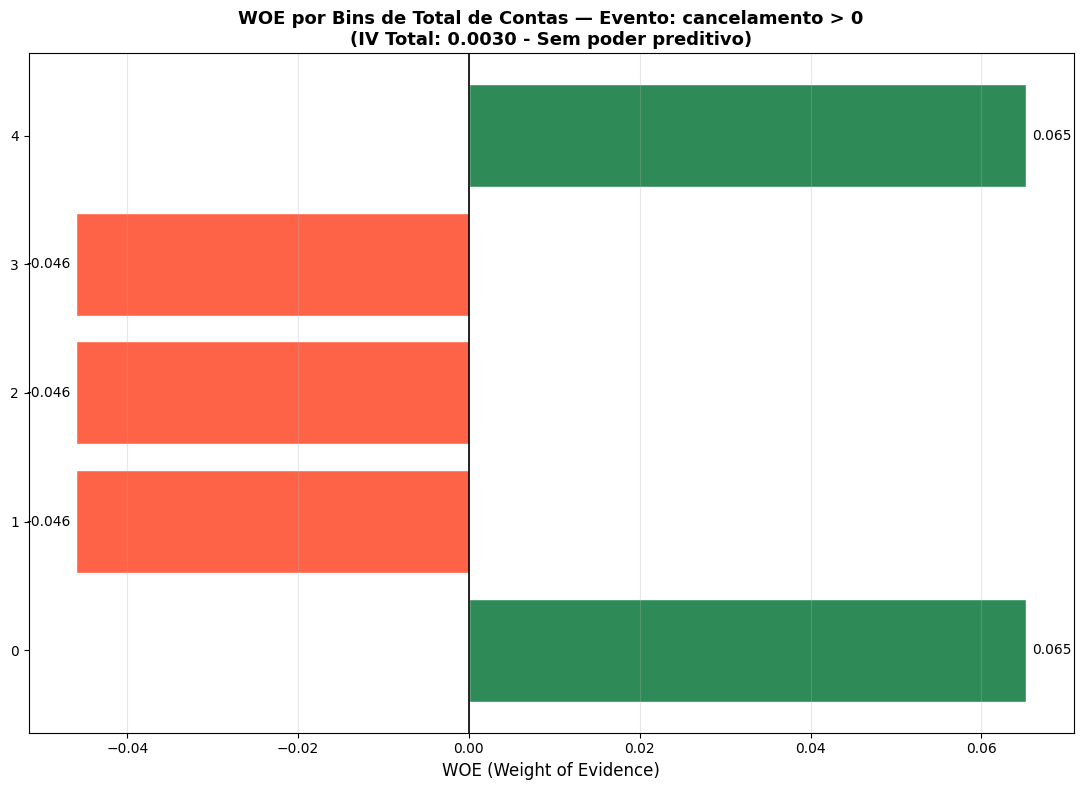

In [ ]:
# Gráfico WOE para 'total_contas_binned'
fig, ax = plt.subplots(figsize=(11, 8)) # Ajuste o tamanho para mais categorias
cores_woe_total_contas = ['seagreen' if w >= 0 else 'tomato' for w in woe_df_total_contas['WOE']]
bars_woe_total_contas  = ax.barh(woe_df_total_contas[col_cat_total_contas], woe_df_total_contas['WOE'], color=cores_woe_total_contas, edgecolor='white')

ax.axvline(0, color='black', linewidth=1.2)
ax.bar_label(bars_woe_total_contas, fmt='%.3f', padding=4, fontsize=10)
ax.set_xlabel('WOE (Weight of Evidence)', fontsize=12)
ax.set_title(f'WOE por Bins de Total de Contas — Evento: cancelamento > 0\n(IV Total: {IV_total_total_contas:.4f} - {interpretar_iv(IV_total_total_contas)})', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Visualização IV parcial para 'total_contas_binned'

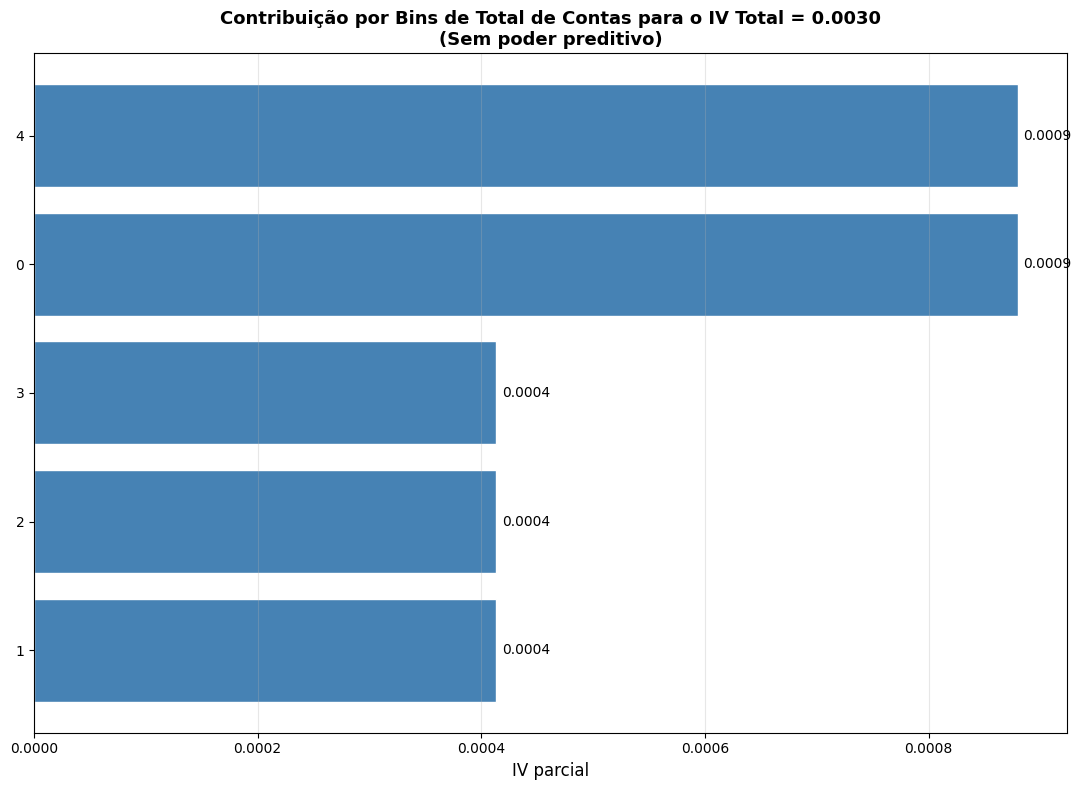

In [ ]:
# Gráfico IV parcial para 'total_contas_binned'
fig, ax = plt.subplots(figsize=(11, 8))
iv_plot_total_contas = woe_df_total_contas.sort_values('IV_parcial')
ax.barh(iv_plot_total_contas[col_cat_total_contas], iv_plot_total_contas['IV_parcial'],
        color='steelblue', edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.4f', padding=4, fontsize=10)
ax.set_xlabel('IV parcial', fontsize=12)
ax.set_title(f'Contribuição por Bins de Total de Contas para o IV Total = {IV_total_total_contas:.4f}\n'+
             f'({interpretar_iv(IV_total_total_contas)})',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Explorando outras colunas em df excel para um target binário

Vamos listar as colunas disponíveis e inspecionar seus valores para identificar um possível target binário com variação.

In [ ]:
print('Colunas disponíveis no df_excel:')
print(df_excel.columns.tolist())

print('\n--- Análise da coluna `valor_cancelamento` ---')
print(f'Valores únicos: {df_excel["valor_cancelamento"].nunique()}')
print('Contagem de valores (top 10):')
print(df_excel['valor_cancelamento'].value_counts().head(10))
print('\nEstatísticas descritivas:')
print(df_excel['valor_cancelamento'].describe())

print('\n--- Análise da coluna `total_contas` ---')
print(f'Valores únicos: {df_excel["total_contas"].nunique()}')
print('Contagem de valores (top 10):')
print(df_excel['total_contas'].value_counts().head(10))
print('\nEstatísticas descritivas:')
print(df_excel['total_contas'].describe())

print('\n--- Análise da coluna `Referencia` ---')
print(f'Valores únicos: {df_excel["Referencia"].nunique()}')
print('Contagem de valores (top 5):')
print(df_excel['Referencia'].value_counts().head(5))

print('\n--- Análise da coluna `DataPrevisao` ---')
print(f'Valores únicos: {df_excel["DataPrevisao"].nunique()}')
print('Contagem de valores (top 5):')
print(df_excel['DataPrevisao'].value_counts().head(5))

Colunas disponíveis no df_excel:
['Referencia', 'DataPrevisao', 'total_contas', 'valor_cancelamento', 'flag_cancelamento', 'total_contas_binned']

--- Análise da coluna `valor_cancelamento` ---
Valores únicos: 42
Contagem de valores (top 10):
valor_cancelamento
64973.83       1
0.25           1
95620.64       1
2880.29        1
12345.21       1
6509.79        1
11379740.15    1
1321443.69     1
15155.63       1
1685.80        1
Name: count, dtype: int64

Estatísticas descritivas:
count    4.200000e+01
mean     9.665573e+05
std      3.062948e+06
min      2.500000e-01
25%      1.960360e+03
50%      1.655235e+04
75%      9.398953e+04
max      1.260441e+07
Name: valor_cancelamento, dtype: float64

--- Análise da coluna `total_contas` ---
Valores únicos: 42
Contagem de valores (top 10):
total_contas
2459        1
1           1
2202        1
95          1
480         1
133         1
11502478    1
6868        1
351         1
57          1
Name: count, dtype: int64

Estatísticas descritivas:
c

### Histograma de valor cancelamento

Vamos visualizar a distribuição dos valores de cancelamento para entender melhor sua dispersão.

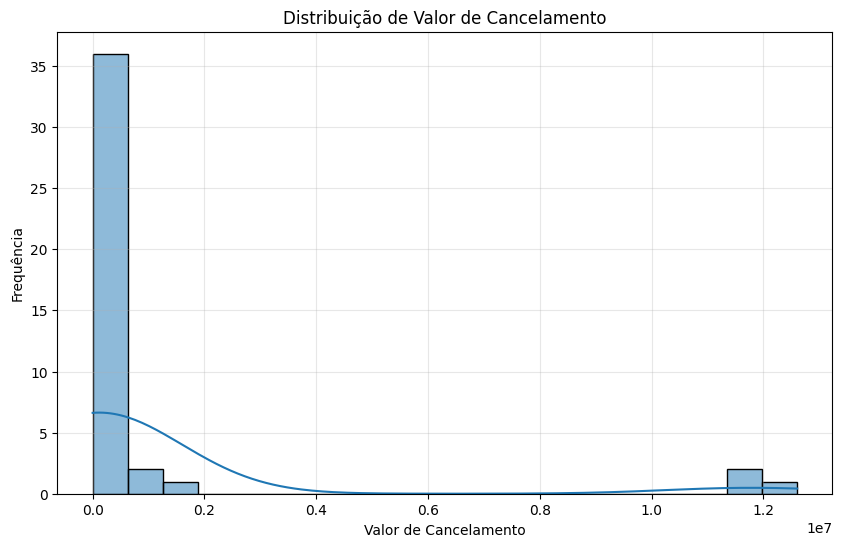

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_excel['valor_cancelamento'], bins=20, kde=True)
plt.title('Distribuição de Valor de Cancelamento')
plt.xlabel('Valor de Cancelamento')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)
plt.show()

### Estatísticas Descritivas Completas do df excel

Vamos exibir as estatísticas descritivas para todas as colunas, incluindo as categóricas, para ter uma visão geral completa dos dados.

In [ ]:
display(df_excel.describe(include='all'))

,Referencia,DataPrevisao,total_contas,valor_cancelamento,flag_cancelamento,total_contas_binned
count,42,42,4.200000e+01,4.200000e+01,42.0,42
unique,42,42,NaN,NaN,NaN,5
top,2021-10-01,2022-09-26 07:37:00,NaN,NaN,NaN,0
freq,1,1,NaN,NaN,NaN,9
mean,NaN,NaN,8.482929e+05,9.665573e+05,1.0,NaN
std,NaN,NaN,3.090876e+06,3.062948e+06,0.0,NaN
min,NaN,NaN,1.000000e+00,2.500000e-01,1.0,NaN
25%,NaN,NaN,1.027500e+02,1.960360e+03,1.0,NaN
50%,NaN,NaN,4.255000e+02,1.655235e+04,1.0,NaN
75%,NaN,NaN,2.136750e+03,9.398953e+04,1.0,NaN


# Conclusões e Insight

A análise realizada permitiu identificar padrões importantes na geração de créditos da Nota Fiscal Paulista, fornecendo à AMA uma ferramenta estratégica para otimizar a arrecadação de recursos.

## Principais Descobertas

### 1. Ajuste da variável de análise trouxe mais precisão

Inicialmente, praticamente todas as notas geravam crédito, o que dificultava qualquer previsão. Para tornar a análise mais útil, a variável foi redefinida para identificar apenas notas com valor de cancelamento acima de R$ 1.000, criando um cenário mais realista e permitindo distinguir quais notas possuem maior potencial de retorno.

### 2. As categorias revelaram os padrões mais importantes

Os valores de cancelamento e o total de contas foram agrupados em categorias que variam de "Muito Baixo" a "Muito Alto". Essa segmentação mostrou que não é apenas o valor individual da nota que importa, mas o perfil em que ela se enquadra.

As análises de WOE (Weight of Evidence) e IV (Information Value) demonstraram que essas categorias possuem forte capacidade preditiva, tornando-se excelentes indicadores para identificar notas com maior potencial de geração de crédito.

### 3. Modelo preditivo com alto desempenho

Utilizando Regressão Logística, foi desenvolvido um modelo capaz de prever com elevada precisão quais notas têm maior probabilidade de gerar crédito significativo.

Os resultados foram validados por meio de validação cruzada, alcançando aproximadamente:

* Acurácia média: 95%
* AUC ROC média: 96%

Esses números demonstram que o modelo apresenta desempenho consistente e confiável para aplicação prática.

### 4. Solução preparada para uso contínuo

Além do treinamento do modelo, foram salvos todos os elementos necessários para sua utilização futura, incluindo regras de categorização, mapas WOE e parâmetros de classificação. Isso garante que novas notas fiscais possam ser analisadas de forma padronizada e segura.

## Recomendações para a AMA

Com base nos resultados, a AMA pode direcionar seus esforços para maximizar a arrecadação:

* Priorizar ações voltadas para notas classificadas nas categorias Médio, Alto e Muito Alto, que apresentaram maior potencial de geração de crédito.
* Desenvolver campanhas educativas para orientar doadores sobre a importância de registrar compras em estabelecimentos com maior potencial de retorno.
* Buscar parcerias com supermercados, farmácias e grandes redes varejistas, que tendem a gerar notas com características mais favoráveis.
* Investigar os casos classificados como Muito Baixo para compreender possíveis limitações e identificar oportunidades de melhoria.

## Conclusão

A análise forneceu um mapa claro dos fatores que influenciam a geração de créditos da Nota Fiscal Paulista. O modelo desenvolvido não apenas apresenta excelente capacidade preditiva, mas também oferece uma base sólida para que a AMA tome decisões mais estratégicas.

Ao concentrar esforços nas categorias com maior potencial de retorno, a associação poderá aumentar a eficiência da arrecadação, ampliar seus recursos e fortalecer ainda mais o apoio oferecido às pessoas autistas e suas famílias.
